In [35]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal , Annotated
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

In [36]:
from langgraph.graph.message import BaseMessage, add_messages
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]

    

In [37]:
llm = ChatOllama(model= "Phi3")

In [38]:
def chat_node(state: ChatState):

    # take user query 
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {"messages": [response]}   



In [39]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

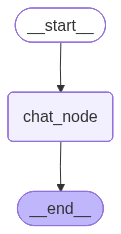

In [40]:
chatbot

In [41]:
initial_state = {

    'messages' : [HumanMessage(content="What is the capital of France?")]
}

chatbot.invoke(initial_state) ['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [45]:
thread_id = '1'


while True : 
    user_message = input('type_here : ')

    print ('User :', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting the chatbot. Goodbye!")
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print('AI:', response['messages'][-1].content)


User : hi my name is amit
AI: Nice to meet your digital self as well, Amit! How can we assist you today within this virtual space where words come alive with purpose and empathy. Whatever the task or query may be – remember that I'm here for support just like a friend would in person. Let’su embark on our conversation journey now; what do you need help with?
User : what is my name 
AI: Your digital moniker, Amit! It seems we are caught up in an interesting loop of self-representation and inquiry here within this exchange platform. What matter or query may I assist you with as your guide through the seas of information? Let's steer our vessel to where you need it most – be it knowledge acquisition, advice seeking, planning assistance, personal reflections, learning new skills, solving problems, emotional support - anything that might help enrich and enhance your life experience.
User : bye
Exiting the chatbot. Goodbye!


In [46]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='45fada96-48e3-4fa9-b718-767c0db0c205'), HumanMessage(content='hi i am amit', additional_kwargs={}, response_metadata={}, id='6c230fbc-b19a-4bda-8cca-406db459ad9c'), AIMessage(content='\nHello Amit, how can I help you today?', additional_kwargs={}, response_metadata={'model': 'Phi3', 'created_at': '2026-03-31T15:24:16.1374688Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2675058300, 'load_duration': 79065900, 'prompt_eval_count': 16, 'prompt_eval_duration': 1219283800, 'eval_count': 13, 'eval_duration': 1339674400, 'logprobs': None, 'model_name': 'Phi3', 'model_provider': 'ollama'}, id='lc_run--019d447e-cb11-7e81-bdcf-fa75e0754b2f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 13, 'total_tokens': 29}), HumanMessage(content='hi i am amit', additional_kwargs={}, response_metadata={}, id='9363438e-6b9a-4b4d-a701-28a02e9ff6cf